# Phase 7: Fisher representation results

This notebook reads completed scalar artifacts only. Fixed-trajectory results measure compression against one shared dense ridge-full auxiliary path; coupled results measure what happens when each representation helps choose its own learning path. The single-replica comparisons are descriptive.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'src').is_dir() and (path / 'mnist_experiment').is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError('Could not locate the amari-chenstov-updates repository root')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.results_analysis import (
    load_phase7_fixed_run,
    load_phase7_coupled_run,
    phase7_fixed_rows,
    phase7_fixed_summaries,
    phase7_coupled_rows,
    phase7_coupled_summaries,
)

RUN_ROOT = REPO_ROOT / 'cache' / 'mnist_experiment' / 'phase7_runs'
FIXED_RUN_ID = 'mnist_lfu_phase7_rank_pilot__replica-0000__14916102ebf92cc3'
COUPLED_RUN_ID = 'mnist_lfu_phase7_coupled_rank8__replica-0000__b0f9fdc792134eb9'

fixed_run = load_phase7_fixed_run(RUN_ROOT / FIXED_RUN_ID)
coupled_run = load_phase7_coupled_run(RUN_ROOT / COUPLED_RUN_ID)
fixed_records = phase7_fixed_rows([fixed_run])
fixed = pd.DataFrame(fixed_records)
fixed_summary = pd.DataFrame(phase7_fixed_summaries(fixed_records))
coupled_records = phase7_coupled_rows([coupled_run])
coupled = pd.DataFrame(coupled_records)
coupled_summary = pd.DataFrame(phase7_coupled_summaries(coupled_records))
print(f'Loaded {FIXED_RUN_ID}')
print(f'Loaded {COUPLED_RUN_ID}')

Loaded mnist_lfu_phase7_rank_pilot__replica-0000__14916102ebf92cc3
Loaded mnist_lfu_phase7_coupled_rank8__replica-0000__b0f9fdc792134eb9


## Fixed-trajectory rank frontier

Rank zero is the explicit diagonal boundary. A condition is labeled numerically unstable when its dense-target relative error exceeds 1 or the clipped residual-diagonal mismatch exceeds 0.1. These labels are derived from stored diagnostics; completed artifacts are never rewritten.

In [2]:
fixed_summary['storage_kib'] = fixed_summary['representation_storage_bytes'] / 1024
stable = fixed_summary[fixed_summary['numerical_status'] == 'completed'].copy()
pareto = []
for _, row in stable.iterrows():
    dominated = ((stable['storage_kib'] <= row['storage_kib']) &
                 (stable['mean_dense_frobenius_error'] <= row['mean_dense_frobenius_error']) &
                 ((stable['storage_kib'] < row['storage_kib']) |
                  (stable['mean_dense_frobenius_error'] < row['mean_dense_frobenius_error']))).any()
    pareto.append(not dominated)
stable['pareto_efficient'] = pareto
fixed_summary = fixed_summary.merge(
    stable[['condition', 'pareto_efficient']], on='condition', how='left'
)
fixed_summary['pareto_efficient'] = fixed_summary['pareto_efficient'].eq(True)
columns = [
    'condition', 'requested_rank', 'mean_realized_rank', 'numerical_status',
    'mean_dense_frobenius_error', 'mean_reference_frobenius_error',
    'mean_matvec_error', 'mean_quadratic_error',
    'mean_leading_eigenvector_alignment', 'maximum_lanczos_diagonal_error',
    'storage_kib', 'mean_update_elapsed_seconds', 'pareto_efficient'
]
print(fixed_summary[columns].to_string(index=False))

            condition  requested_rank  mean_realized_rank     numerical_status  mean_dense_frobenius_error  mean_reference_frobenius_error  mean_matvec_error  mean_quadratic_error  mean_leading_eigenvector_alignment  maximum_lanczos_diagonal_error  storage_kib  mean_update_elapsed_seconds  pareto_efficient
             diagonal               0               0.000            completed                    0.977646                        0.983292           0.980096              1.721027                            0.334062                        0.000000          4.0                     0.014043              True
 low_rank_diagonal_r4               4               4.000            completed                    0.198151                        0.464252           0.210815              0.220626                            0.992916                        0.000474         20.0                     0.014917              True
 low_rank_diagonal_r8               8               8.000            complet

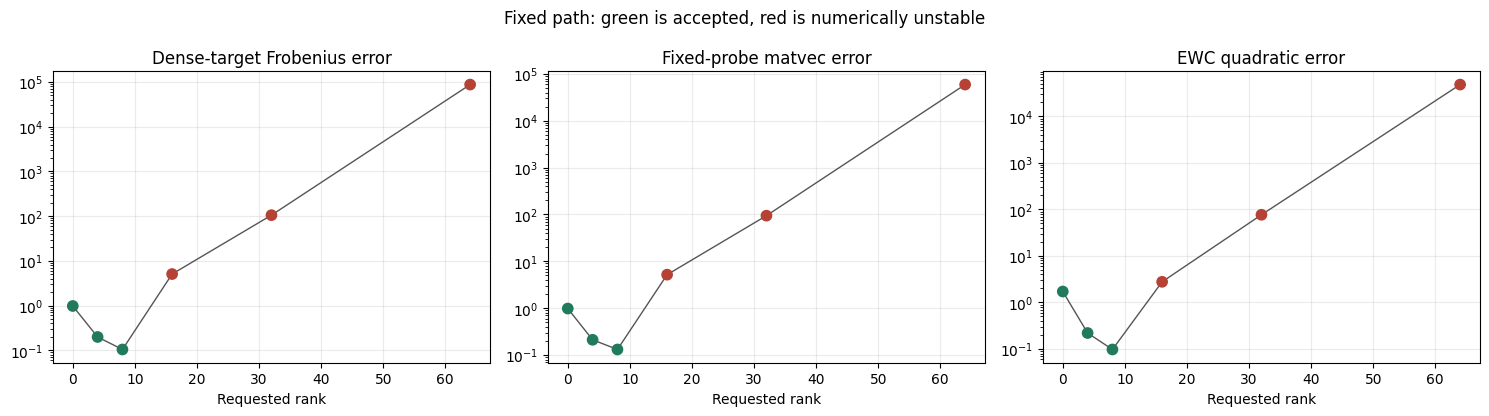

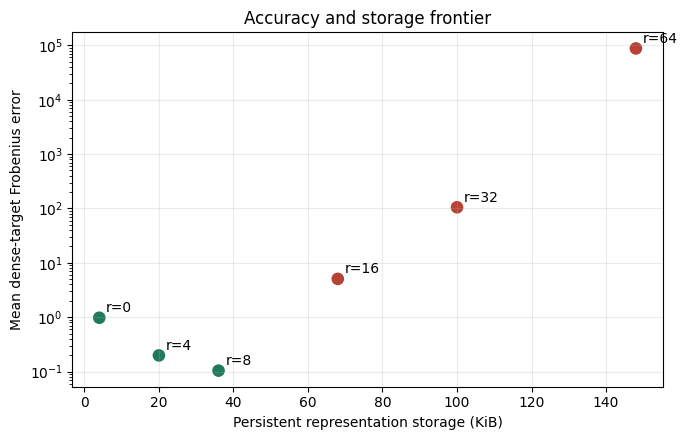

In [3]:
ordered = fixed_summary.sort_values('requested_rank')
colors = ['#217a5b' if value == 'completed' else '#b64235' for value in ordered['numerical_status']]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
metrics = [
    ('mean_dense_frobenius_error', 'Dense-target Frobenius error'),
    ('mean_matvec_error', 'Fixed-probe matvec error'),
    ('mean_quadratic_error', 'EWC quadratic error'),
]
for axis, (metric, title) in zip(axes, metrics):
    axis.plot(ordered['requested_rank'], ordered[metric], color='#555555', linewidth=1)
    axis.scatter(ordered['requested_rank'], ordered[metric], c=colors, s=55, zorder=3)
    axis.set_yscale('log')
    axis.set_xlabel('Requested rank')
    axis.set_title(title)
    axis.grid(alpha=0.25)
fig.suptitle('Fixed path: green is accepted, red is numerically unstable')
fig.tight_layout()

fig, axis = plt.subplots(figsize=(7, 4.5))
axis.scatter(ordered['storage_kib'], ordered['mean_dense_frobenius_error'], c=colors, s=65)
for _, row in ordered.iterrows():
    axis.annotate(f"r={int(row['requested_rank'])}", (row['storage_kib'], row['mean_dense_frobenius_error']), xytext=(5, 4), textcoords='offset points')
axis.set_yscale('log')
axis.set_xlabel('Persistent representation storage (KiB)')
axis.set_ylabel('Mean dense-target Frobenius error')
axis.set_title('Accuracy and storage frontier')
axis.grid(alpha=0.25)
fig.tight_layout()

## Coupled representation paths

Only rank 8 survived the fixed-path screen. The dense and rank-8 conditions use the same ridge-full LFU treatment; the Fisher representation is the treatment difference. Diagonal is retained as the rank-zero boundary.

              method    representation  mean_fisher_error  final_fisher_error  final_nll  final_nine_nll  final_non_nine_nll  final_balanced_accuracy  final_distance_from_initial  mean_update_elapsed_seconds
    dense_ridge_full             dense           0.246479            0.072163   2.348048       19.906482            0.377582                 0.798056                     0.321793                     0.056633
 diagonal_ridge_full          diagonal           2.070688            7.492336   1.052822        0.261245            1.141656                 0.624246                     1.082371                     0.026853
low_rank_diagonal_r8 low_rank_diagonal           0.254962            0.073761   2.346427       19.892564            0.377341                 0.797107                     0.322784                     0.050704


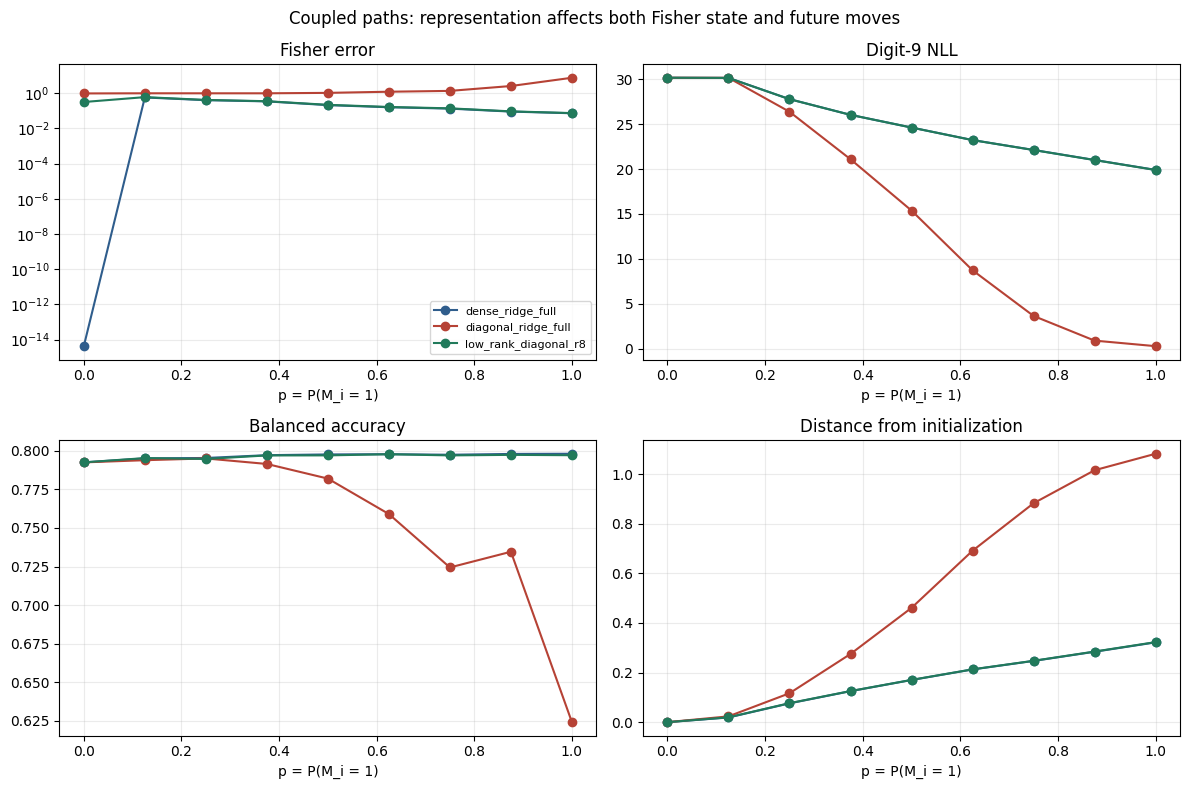

In [4]:
columns = [
    'method', 'representation', 'mean_fisher_error', 'final_fisher_error',
    'final_nll', 'final_nine_nll', 'final_non_nine_nll',
    'final_balanced_accuracy', 'final_distance_from_initial',
    'mean_update_elapsed_seconds'
]
print(coupled_summary[columns].to_string(index=False))

palette = {
    'dense_ridge_full': '#2f5d8c',
    'diagonal_ridge_full': '#b64235',
    'low_rank_diagonal_r8': '#217a5b',
}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
series = [
    ('relative_frobenius_error', 'Fisher error', True),
    ('before_nine_nll', 'Digit-9 NLL', False),
    ('before_balanced_accuracy', 'Balanced accuracy', False),
    ('distance_from_initial', 'Distance from initialization', False),
]
for axis, (metric, title, log_scale) in zip(axes.flat, series):
    for method, group in coupled.groupby('method'):
        group = group.sort_values('p')
        axis.plot(group['p'], group[metric], marker='o', label=method, color=palette[method])
    if log_scale:
        axis.set_yscale('log')
    axis.set_xlabel('p = P(M_i = 1)')
    axis.set_title(title)
    axis.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Coupled paths: representation affects both Fisher state and future moves')
fig.tight_layout()

## Interpretation

Rank 8 is the practical survivor in this replica: it closely reproduces dense ridge-full Fisher tracking and the resulting parameter path at a small fraction of dense persistent storage. The diagonal condition does not merely approximate the same path poorly; its EWC decisions drive a materially different path. Ranks 16 and above expose loss of numerical control in the copied unreorthogonalized Lanczos recurrence, so increasing requested rank is not monotone. This supports retaining the copied source for provenance while replacing or reorthogonalizing the recurrence before any future higher-rank study.

In [5]:
fixed_bytes = sum(fixed_run.metrics['artifact_files_bytes'].values())
coupled_bytes = sum(coupled_run.metrics['artifact_files_bytes'].values())
print(pd.DataFrame([
    {'evidence': 'fixed_rank_sweep', 'run_id': fixed_run.run_id, 'artifact_MiB': fixed_bytes / 2**20, 'elapsed_seconds': fixed_run.metrics['total_elapsed_seconds']},
    {'evidence': 'structured_coupled', 'run_id': coupled_run.run_id, 'artifact_MiB': coupled_bytes / 2**20, 'elapsed_seconds': coupled_run.metrics['total_elapsed_seconds']},
]).to_string(index=False))

          evidence                                                         run_id  artifact_MiB  elapsed_seconds
  fixed_rank_sweep    mnist_lfu_phase7_rank_pilot__replica-0000__14916102ebf92cc3     22.504143         9.055158
structured_coupled mnist_lfu_phase7_coupled_rank8__replica-0000__b0f9fdc792134eb9    103.751853        49.671779
